# Gradient Boosting Model

This is our third and final model. We have already trained Logistic Regression
as a simple linear baseline and Random Forest as a parallel ensemble.
Now we try Gradient Boosting — a different kind of ensemble that works in a
completely opposite way to Random Forest.

Instead of building hundreds of trees independently and letting them vote,
Gradient Boosting builds trees one at a time, where each new tree looks at
the mistakes of the previous ones and tries to fix them.
It is slower to train but often the most accurate of the three.

## Importing Libraries

Same tools as the previous two notebooks — keeping everything consistent
so the final comparison is fair.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

## Loading the Preprocessed Data

Same arrays as Logistic Regression and Random Forest.
This is the third and last model trained on these exact splits —
after this we bring all three together in the evaluation notebook.

In [13]:
X_train = np.load('../data/X_train_processed.npy')
X_test  = np.load('../data/X_test_processed.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)

print(f'\nClass distribution in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Good credit' if u == 0 else 'Bad credit'
    print(f'  {label} ({int(u)}): {c} samples ({c/len(y_train)*100:.1f}%)')

X_train shape: (800, 44)
X_test shape:  (200, 44)

Class distribution in training set:
  Good credit (0): 560 samples (70.0%)
  Bad credit (1): 240 samples (30.0%)


## What is Gradient Boosting?

The best way to understand Gradient Boosting is through a simple analogy.

Imagine you are trying to guess someone's age from a photo.
You make a first guess — say 35. You were off by 8 years, the real age is 43.
A second person looks at your mistake and says *'you were 8 years too low'*
and adds a correction of +5. Now the estimate is 40, still off by 3.
A third person adds another small correction. And so on.

Each person is not trying to guess the age from scratch —
they are only trying to fix what the previous people got wrong.
That is exactly how Gradient Boosting works.

**Step by step:**

1. Start with a simple first prediction — usually just the average
2. Calculate the errors (called **residuals**) — how wrong was each prediction?
3. Train a small tree to predict those residuals — not the target, just the mistakes
4. Add that tree's corrections to the current predictions, scaled by the learning rate:

$$F_{m}(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Where $F_{m-1}(x)$ is what we predicted so far, $h_m(x)$ is the new correction tree,
and $\eta$ is the learning rate — how much we trust each correction.

5. Repeat this process for as many trees as we set

The word **Gradient** comes from the fact that the residuals we fit at each step
are mathematically the gradient of the loss function — we are doing gradient descent,
but instead of updating weights like in neural networks, we are adding new trees.

**How is this different from Random Forest?**

| | Random Forest | Gradient Boosting |
|---|---|---|
| Trees built | All at once, independently | One at a time, each fixing the last |
| What each tree predicts | The target directly | The mistakes of the previous trees |
| Overfitting risk | Lower | Higher — needs careful tuning |
| Training speed | Fast (parallel) | Slower (sequential) |
| Typical accuracy | High | Usually the highest of the three |

## Handling the Class Imbalance

You might remember that in Logistic Regression and Random Forest we used
`class_weight='balanced'` to deal with the 70/30 imbalance.

Gradient Boosting does not support that parameter directly.
Instead we pass `sample_weight` when calling `fit()` — it achieves the exact
same result by telling the model to pay more attention to bad credit samples
during training.

We use scikit-learn's `compute_sample_weight` to calculate the right weights automatically.

In [14]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print('Sample weights assigned:')
print(f'  Weight for Good credit (0): {sample_weights[y_train == 0][0]:.4f}')
print(f'  Weight for Bad credit  (1): {sample_weights[y_train == 1][0]:.4f}')
print(f'\nBad credit samples are weighted '
      f'{sample_weights[y_train==1][0]/sample_weights[y_train==0][0]:.2f}x '
      f'more than good credit samples')

Sample weights assigned:
  Weight for Good credit (0): 0.7143
  Weight for Bad credit  (1): 1.6667

Bad credit samples are weighted 2.33x more than good credit samples


## Model Settings

Gradient Boosting needs more careful tuning than Random Forest because
the sequential nature makes it easier to overfit.

- **`n_estimators=300`** — we build 300 correction trees.
  This always works together with the learning rate — more trees need
  a smaller learning rate to avoid going too far with the corrections.

- **`learning_rate=0.05`** — each tree contributes only 5% of its correction.
  This sounds small but is actually the right approach — small steps
  in the right direction lead to a more stable and accurate final model.
  Think of it like adjusting the volume on a speaker very gradually
  rather than turning the dial all the way at once.

- **`max_depth=4`** — trees are kept very shallow on purpose.
  In Gradient Boosting each tree only needs to capture one small pattern
  — the residuals from the previous round. Deep trees here would overfit badly.

- **`min_samples_split=20`** — a node needs at least 20 samples to split.
  Higher than Random Forest because GB trees are more sensitive to noise.

- **`min_samples_leaf=10`** — every leaf needs at least 10 samples.
  Prevents the model from learning rules that only apply to a tiny group.

- **`subsample=0.8`** — each tree only sees 80% of the training data,
  chosen randomly. This introduces some randomness into the process
  and helps prevent overfitting — this technique is called
  Stochastic Gradient Boosting.

- **`max_features='sqrt'`** — at each split only consider a random subset
  of features, same idea as Random Forest.

## Training the Model

Because each tree depends on the results of the previous one,
Gradient Boosting cannot be parallelised like Random Forest.
Training 300 trees sequentially takes longer — typically 30 seconds to a few minutes
depending on the machine.

In [15]:
gb_model = GradientBoostingClassifier(n_estimators=300,learning_rate=0.05, max_depth=4, min_samples_split=20, min_samples_leaf=10,subsample=0.8,
    max_features='sqrt',random_state=42)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)
print('Gradient Boosting trained successfully.')
print(f'Number of trees built: {gb_model.n_estimators_}')

Gradient Boosting trained successfully.
Number of trees built: 300


## Making Predictions

Same as before — hard labels for the confusion matrix
and probabilities for the ROC-AUC score.

In [16]:
y_pred       = gb_model.predict(X_test)
y_pred_proba = gb_model.predict_proba(X_test)[:, 1]

print('Sample predictions (first 10):')
print('Predicted:', y_pred[:10])
print('Actual:   ', y_test[:10].astype(int))

Sample predictions (first 10):
Predicted: [0 0 1 1 0 0 0 0 1 0]
Actual:    [0 0 1 0 1 0 0 0 0 0]


## Evaluating the Model

Same metrics as Logistic Regression and Random Forest.
The question we want to answer here is simple:
did the extra complexity of Gradient Boosting actually pay off?

In [17]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('      GRADIENT BOOSTING RESULTS')
print('=' * 45)
print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  ROC-AUC  : {roc_auc:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Good Credit', 'Bad Credit']
))

      GRADIENT BOOSTING RESULTS
  Accuracy : 0.7200 (72.00%)
  ROC-AUC  : 0.7810

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.86      0.72      0.78       140
  Bad Credit       0.52      0.72      0.61        60

    accuracy                           0.72       200
   macro avg       0.69      0.72      0.69       200
weighted avg       0.76      0.72      0.73       200



Gradient Boosting achieved an accuracy of 72.00% and a ROC-AUC of 0.7810 — which is actually slightly lower than both Logistic Regression (0.7819) and Random Forest (0.7920). This is an important and honest result — more complexity does not always mean better performance. On this dataset, with only 1000 samples, Gradient Boosting did not manage to outperform the simpler models.

For the Bad Credit class, recall is 0.72 — sitting between Logistic Regression (0.77) and Random Forest (0.67). Precision is 0.52, similar to the other two models. The F1-score of 0.61 is consistent with what we saw before.

For the Good Credit class, precision of 0.86 is the highest of the three models — meaning when Gradient Boosting says someone is a good applicant, it is right 86% of the time. Recall of 0.72 however means it missed more good applicants than the others.

The overall picture is that all three models perform in a similar range, with no single model dominating across all metrics. This makes the evaluation notebook even more important — we need to look at the full picture to decide which model to recommend.

## Confusion Matrix

Same breakdown as before — we focus on the False Negatives
(bad applicants we missed) as the most expensive type of error,
and compare the numbers to what we saw in the previous two models.

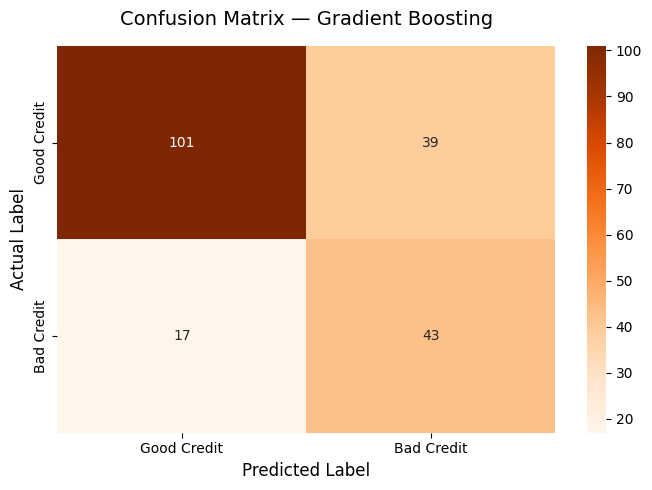

True Negatives  (correctly predicted good): 101
False Positives (good applicants flagged):  39
False Negatives (bad applicants missed):    17  <- most costly
True Positives  (correctly caught bad):     43


In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges',
    xticklabels=['Good Credit', 'Bad Credit'],
    yticklabels=['Good Credit', 'Bad Credit']
)
plt.title('Confusion Matrix — Gradient Boosting', fontsize=14, pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted good): {tn}')
print(f'False Positives (good applicants flagged):  {fp}')
print(f'False Negatives (bad applicants missed):    {fn}  <- most costly')
print(f'True Positives  (correctly caught bad):     {tp}')

Out of 200 test applicants, the model correctly classified 101 good credit and 43 bad credit applicants.

The False Negatives are 17 — Gradient Boosting missed 17 out of 60 bad applicants, which means 28% of actual bad credit cases slipped through undetected. This is better than Random Forest which missed 20, but worse than Logistic Regression which only missed 14.

The False Positives are 39 — we wrongly rejected 39 good customers, which is slightly better than Logistic Regression's 41 but not as good as Random Forest's 33.

Overall Gradient Boosting sits right in the middle of the other two models on both types of errors — not the best at catching bad applicants, not the best at protecting good ones, but a reasonable balance between the two.

## ROC Curve

The ROC curve for Gradient Boosting — this will be the last individual curve
before we overlay all three in the evaluation notebook.
A higher and steeper curve means the model is better at separating
good from bad applicants at every possible threshold.

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


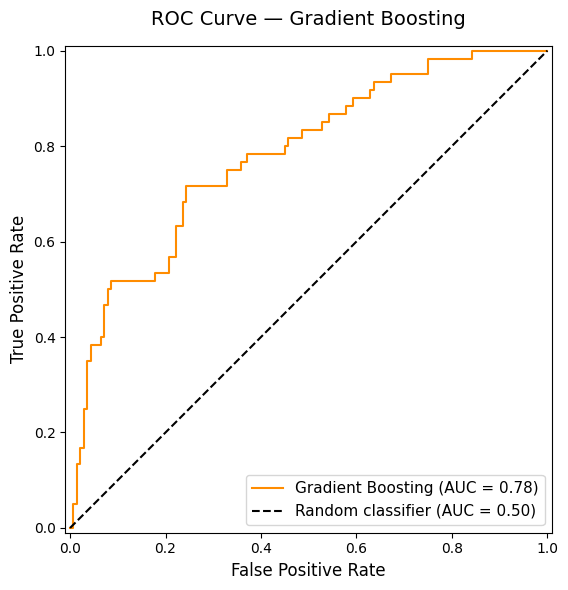

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, name='Gradient Boosting', color='darkorange',  ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.50)')
ax.set_title('ROC Curve — Gradient Boosting', fontsize=14, pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The curve sits well above the diagonal, confirming the model is meaningfully better than random guessing.

The AUC of 0.78 is the lowest of the three models — Random Forest achieved 0.79 and Logistic Regression 0.78 as well, so they are essentially tied. Looking at the curve shape, there is a nice steep rise early on but it flattens out sooner than we would like, which explains why the overall area is slightly lower than Random Forest.

This confirms what we saw in the classification report — Gradient Boosting did not bring the improvement we hoped for on this dataset. More complexity did not translate into better separation between good and bad applicants.

## Feature Importance

Just like Random Forest, Gradient Boosting tells us which features it found
most useful across all 300 trees.

This is particularly interesting to compare with the Random Forest importance plot.
Features that appear important in all three models — Logistic Regression coefficients,
Random Forest importance, and Gradient Boosting importance — are the ones we can
be most confident about as genuine drivers of credit risk.

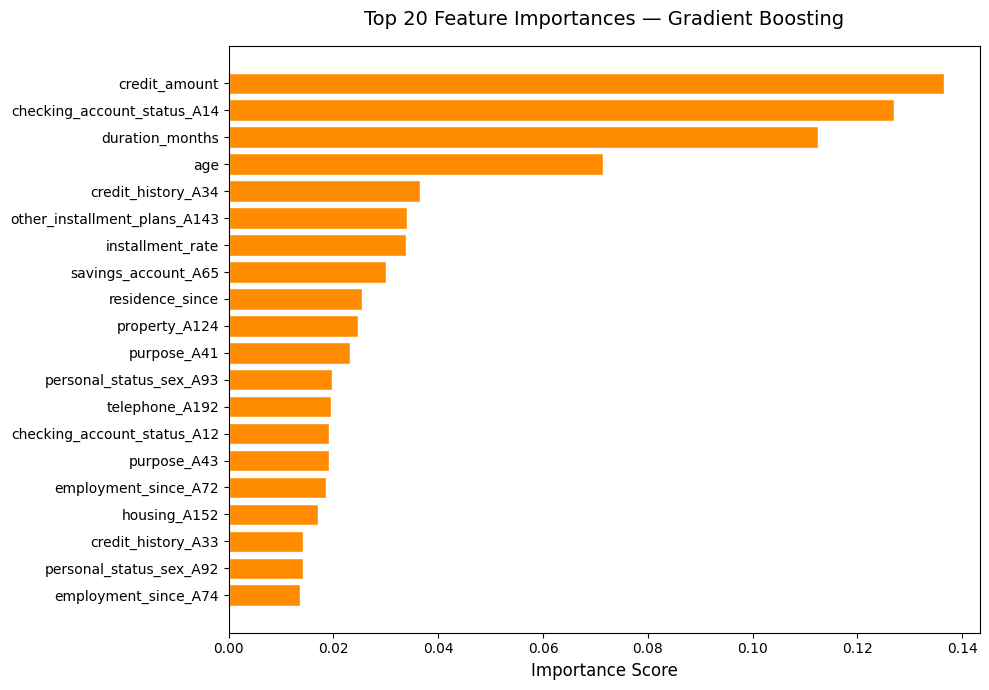

Top 10 most important features:
credit_amount                   0.1366
checking_account_status_A14     0.1270
duration_months                 0.1125
age                             0.0714
credit_history_A34              0.0365
other_installment_plans_A143    0.0340
installment_rate                0.0339
savings_account_A65             0.0300
residence_since                 0.0254
property_A124                   0.0246
dtype: float64


In [20]:
importances = pd.Series(gb_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(range(len(top_features)),top_features.values[::-1],color='darkorange', edgecolor='white')
plt.yticks(range(len(top_features)), top_features.index[::-1], fontsize=10)
plt.title('Top 20 Feature Importances — Gradient Boosting', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(top_features.head(10).round(4))

The top three features are `credit_amount` (0.137), `checking_account_status_A14` (0.127), and `duration_months` (0.113) — the exact same three features that dominated Random Forest, just in a slightly different order.

This is a very important finding. These three variables have now appeared at the top of all three models — Logistic Regression coefficients, Random Forest importance, and Gradient Boosting importance. That consistency across completely different algorithms gives us strong confidence that credit amount, loan duration, and checking account status are the real drivers of credit risk in this dataset, not just patterns picked up by one particular model.

`age` (0.071) and `credit_history_A34` (0.037) also appear in all three models' top lists, further reinforcing their importance.

## Learning Curve

This is something unique to Gradient Boosting — we can watch the model
improve tree by tree using `staged_predict_proba()`.

The learning curve shows the ROC-AUC on both the training and test sets
as we add more trees. It answers two important questions:

- **Is 300 trees enough?** If the test curve is still going up at tree 300,
  we might want more. If it has already flattened, 300 is fine.
- **Is the model overfitting?** If the training curve keeps rising but
  the test curve starts dropping, that is overfitting.
  A well-tuned model shows both curves close together and flattening out.

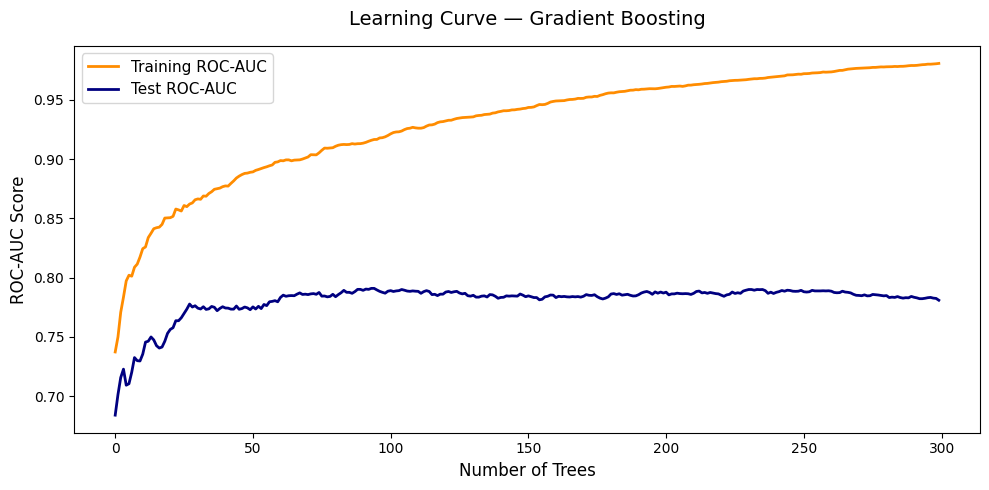

Best test ROC-AUC reached at tree 94: 0.7910
Final test ROC-AUC at tree 300:            0.7810


In [21]:
train_scores = []
test_scores  = []

for y_proba in gb_model.staged_predict_proba(X_train):
    train_scores.append(roc_auc_score(y_train, y_proba[:, 1]))

for y_proba in gb_model.staged_predict_proba(X_test):
    test_scores.append(roc_auc_score(y_test, y_proba[:, 1]))

plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training ROC-AUC', color='darkorange', linewidth=2)
plt.plot(test_scores,  label='Test ROC-AUC',     color='navy',       linewidth=2)
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Learning Curve — Gradient Boosting', fontsize=14, pad=15)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

best_n = int(np.argmax(test_scores)) + 1
print(f'Best test ROC-AUC reached at tree {best_n}: {max(test_scores):.4f}')
print(f'Final test ROC-AUC at tree 300:            {test_scores[-1]:.4f}')


This plot tells a very clear story. The test curve (dark blue) rises quickly in the first 50 trees, reaching around 0.79, and then essentially flattens out for the remaining 250 trees. Adding more trees beyond 50 brought almost no improvement on unseen data.

The training curve (orange) however keeps climbing all the way to 0.97 at tree 300. This gap between training (0.97) and test (0.78) performance is a sign of mild overfitting — the model learned the training data very well but that extra learning did not transfer to new applicants.

This explains exactly why Gradient Boosting did not beat Random Forest on this dataset. The model had essentially learned everything useful from the data by around tree 50, and the remaining 250 trees were mostly fitting noise in the training set rather than real patterns.

In a future improvement, we could retrain with only 50-100 trees and a slightly higher learning rate, which would give the same test performance with much faster training.

## Saving the Model

We save the trained model so it can be loaded in the evaluation notebook
alongside Logistic Regression and Random Forest for the final comparison.

In [22]:
os.makedirs('../models', exist_ok=True)

joblib.dump(gb_model, '../models/gradient_boosting.pkl')
print('Model saved to ../models/gradient_boosting.pkl')

gb_metrics = {
    'model':    'Gradient Boosting',
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'roc_auc':  round(roc_auc_score(y_test, y_pred_proba), 4)
}

print()
print('Metrics summary:')
for k, v in gb_metrics.items():
    print(f'  {k}: {v}')

Model saved to ../models/gradient_boosting.pkl

Metrics summary:
  model: Gradient Boosting
  accuracy: 0.72
  roc_auc: 0.781
